##               **RESUME SCREENING PROJECT**




In [1]:
# importing the data sets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


  ## **Upload The Dataset**



In [3]:
df = pd.read_csv("ai_resume_screening.csv")
df

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes
...,...,...,...,...,...,...,...
29995,9,77.4,Bachelors,13,691,434,Yes
29996,5,77.8,Bachelors,9,473,149,No
29997,1,64.6,Bachelors,7,247,82,No
29998,7,94.8,Bachelors,12,584,409,Yes


In [4]:
df.shape

(30000, 7)

In [5]:
df.columns

Index(['years_experience', 'skills_match_score', 'education_level',
       'project_count', 'resume_length', 'github_activity', 'shortlisted'],
      dtype='object')

In [6]:
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [7]:
df.tail()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
29995,9,77.4,Bachelors,13,691,434,Yes
29996,5,77.8,Bachelors,9,473,149,No
29997,1,64.6,Bachelors,7,247,82,No
29998,7,94.8,Bachelors,12,584,409,Yes
29999,14,77.3,Masters,25,694,790,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  object 
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB


In [9]:
df.describe()

,years_experience,skills_match_score,project_count,resume_length,github_activity
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,7.506567,73.682653,10.646267,572.584700,325.260667
std,4.624104,16.765909,4.634047,178.709918,159.951803
min,0.000000,0.500000,0.000000,150.000000,0.000000
25%,3.750000,62.100000,7.000000,441.000000,202.000000
50%,7.000000,74.300000,10.000000,574.000000,321.000000
75%,12.000000,86.500000,14.000000,709.000000,443.000000
max,15.000000,100.000000,25.000000,900.000000,842.000000


         
 #       **Data Cleaning**

In [10]:
df.isnull().sum()

,0
years_experience,0
skills_match_score,0
education_level,0
project_count,0
resume_length,0
github_activity,0
shortlisted,0


In [11]:
df.duplicated().sum()

np.int64(0)

#      **Exploratory Data Analysis**

In [12]:
df['shortlisted'].value_counts()

,count
shortlisted,
Yes,20966
No,9034


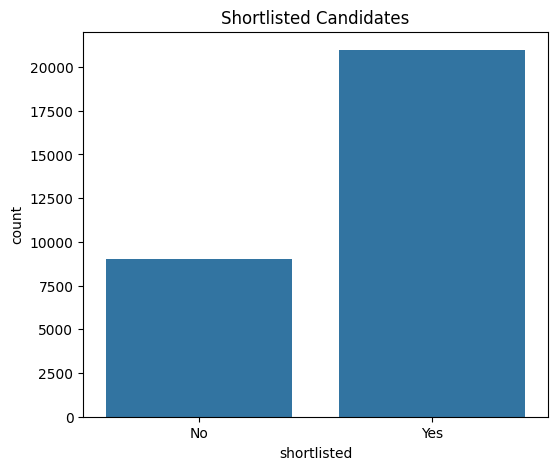

In [19]:
# To show the count of shortlisted candidates
plt.figure(figsize=(6,5))

sns.countplot(x='shortlisted',data=df)

plt.title("Shortlisted Candidates")
plt.show()

In [14]:
x=df["education_level"].value_counts()
x

,count
education_level,
Bachelors,13461
Masters,10524
PhD,3024
High School,2991


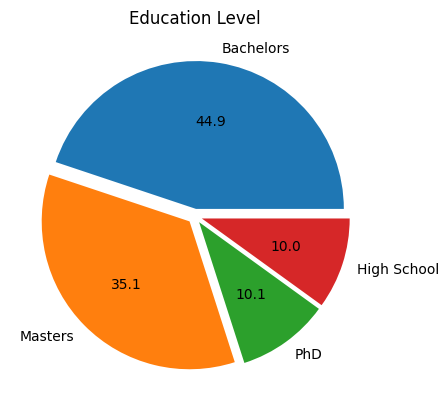

In [15]:
# Education level
plt.pie(x,labels=x.index,autopct='%1.1f',explode=[0.05,0.05,0.05,0.05])

plt.title("Education Level")
plt.show()

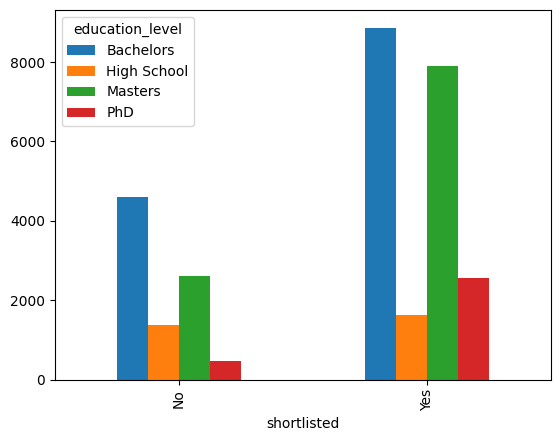

In [20]:
#shortlisted based on the Education Level

pd.crosstab(df["shortlisted"],df["education_level"]).plot(kind="bar")
plt.show()

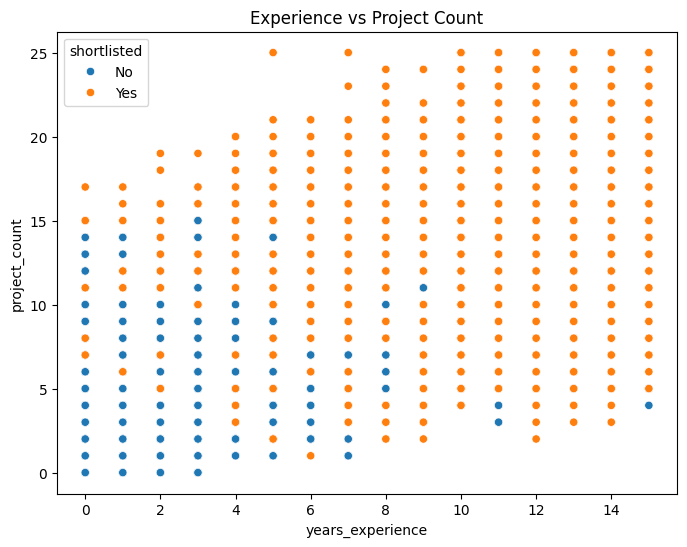

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='years_experience',
    y='project_count',
    hue='shortlisted',
    data=df
)

plt.title("Experience vs Project Count")
plt.show()

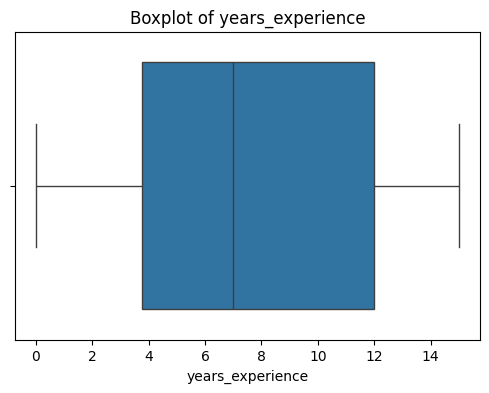

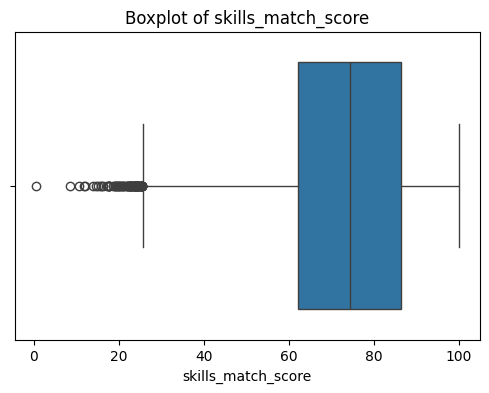

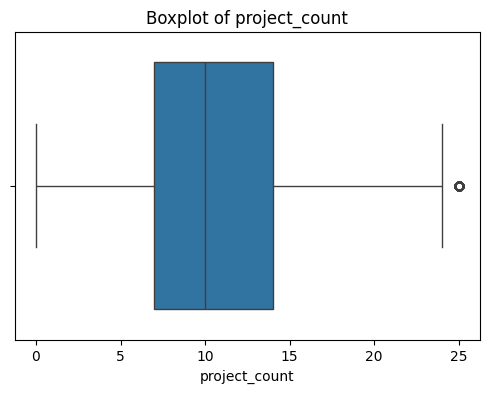

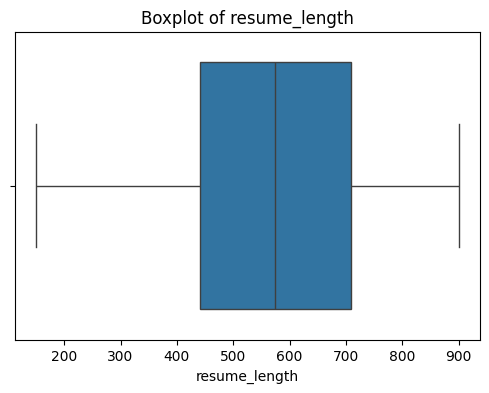

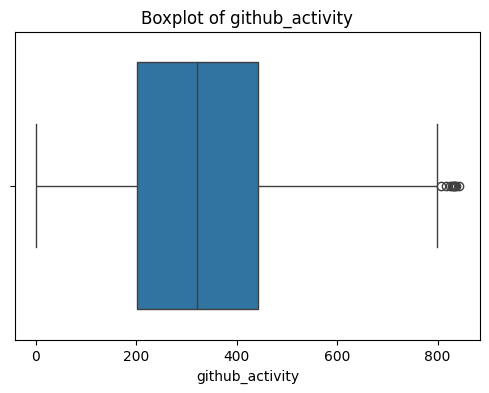

In [ ]:
numerical_columns = [
    'years_experience',
    'skills_match_score',
    'project_count',
    'resume_length',
    'github_activity'
]

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Label Encoding




In [21]:
from sklearn.preprocessing import LabelEncoder


In [22]:
le = LabelEncoder()

In [27]:
df["education_level"]=le.fit_transform(df["education_level"])
df
# Bachelors --->0
# High School --->1
# Masters --->2
# PhD --->3


,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,0,7,234,158,0
1,3,59.1,2,5,502,77,0
2,12,100.0,2,12,753,381,1
3,14,66.8,1,8,529,407,1
4,10,99.6,0,10,754,331,1
...,...,...,...,...,...,...,...
29995,9,77.4,0,13,691,434,1
29996,5,77.8,0,9,473,149,0
29997,1,64.6,0,7,247,82,0
29998,7,94.8,0,12,584,409,1


In [26]:
df["shortlisted"]=le.fit_transform(df["shortlisted"])
df
# No--->0
# Yes--->1

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,0,7,234,158,0
1,3,59.1,2,5,502,77,0
2,12,100.0,2,12,753,381,1
3,14,66.8,1,8,529,407,1
4,10,99.6,0,10,754,331,1
...,...,...,...,...,...,...,...
29995,9,77.4,0,13,691,434,1
29996,5,77.8,0,9,473,149,0
29997,1,64.6,0,7,247,82,0
29998,7,94.8,0,12,584,409,1


#Seperating the Target column


In [65]:
x=df.drop("shortlisted",axis=1)
x

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity
0,6,84.7,0,7,234,158
1,3,59.1,2,5,502,77
2,12,100.0,2,12,753,381
3,14,66.8,1,8,529,407
4,10,99.6,0,10,754,331
...,...,...,...,...,...,...
29995,9,77.4,0,13,691,434
29996,5,77.8,0,9,473,149
29997,1,64.6,0,7,247,82
29998,7,94.8,0,12,584,409


In [66]:
y=df["shortlisted"]
y

,shortlisted
0,0
1,0
2,1
3,1
4,1
...,...
29995,1
29996,0
29997,0
29998,1


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

In [90]:
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.2)


##**Model** **Training**

In [91]:
# IMPORT MACHINE LEARNING ALGORITHMS

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Logistic Regression

In [92]:
lr = LogisticRegression()

In [93]:
lr.fit(train_x, train_y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [97]:
lr_pred = lr.predict(test_x)
lr_pred

array([1, 1, 0, ..., 1, 1, 0])

In [98]:
test_y

,shortlisted
23438,1
16826,1
8976,0
2325,1
17317,1
...,...
22898,1
8183,1
4512,1
20794,0


In [126]:
# Accuracy
lr_accuracy=lr.score(test_x,test_y)*100
lr_accuracy

89.0

# 2. Decision Tree





In [116]:
dt = DecisionTreeClassifier(criterion="entropy")

In [117]:
dt.fit(train_x,train_y)

DecisionTreeClassifier(criterion='entropy')

In [118]:
dt_pred = dt.predict(test_x)

In [119]:
dt_pred

array([1, 1, 0, ..., 1, 1, 0])

In [120]:
test_y

,shortlisted
23438,1
16826,1
8976,0
2325,1
17317,1
...,...
22898,1
8183,1
4512,1
20794,0


In [124]:
dt_accuracy=accuracy_score(test_y,dt_pred)*100
dt_accuracy

86.15

##3. RandomForest

In [108]:
rf = RandomForestClassifier(n_estimators=100)

In [109]:
rf.fit(train_x,train_y)

RandomForestClassifier()

In [141]:
rf_pred=rf.predict(test_x)
rf_pred

array([1, 1, 0, ..., 1, 1, 0])

In [142]:
test_y

,shortlisted
23438,1
16826,1
8976,0
2325,1
17317,1
...,...
22898,1
8183,1
4512,1
20794,0


In [145]:
result = pd.DataFrame({
    "Actual": test_y,
    "Predicted": rf_pred
})

result.head(10)

,Actual,Predicted
23438,1,1
16826,1,1
8976,0,0
2325,1,0
17317,1,1
7145,1,1
27467,0,0
25399,1,1
10739,1,1
19384,1,1


In [122]:
rf_accuracy=accuracy_score(test_y,y_pred)*100
rf_accuracy

90.45

##Model Comparision





In [135]:
comparison = pd.DataFrame({"Model":["Logistic Regression","Decision Tree","Random Forest"],
                           "Accuracy":[lr_accuracy,dt_accuracy,rf_accuracy]})
comparison

,Model,Accuracy
0,Logistic Regression,89.00
1,Decision Tree,86.15
2,Random Forest,90.45


# Accuracy comparision Graph

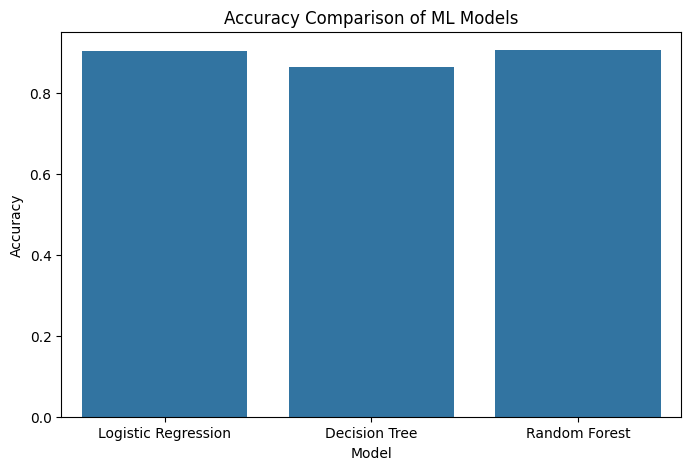

In [82]:

plt.figure(figsize=(8,5))

sns.barplot(data=comparison, x="Model", y="Accuracy")

plt.title("Accuracy Comparison of ML Models")


plt.show()

# Take Randome Forest
Because Randome Forest give highest Accuracy



In [136]:
cm=confusion_matrix(test_y,rf_pred)
cm

array([[ 539, 1290],
       [1241, 2930]])

Text(50.722222222222214, 0.5, 'Predicted')

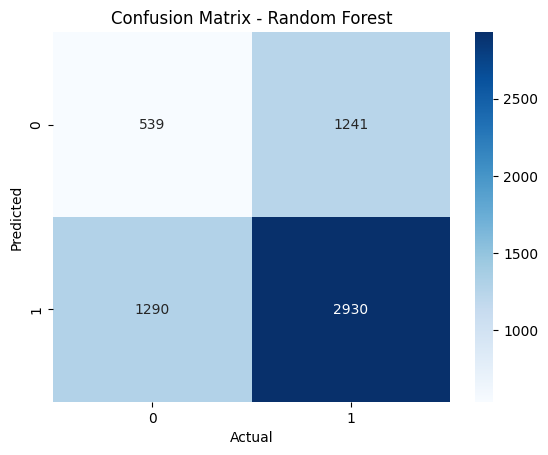

In [139]:
sns.heatmap(cm.T,annot=True,cmap="Blues",fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Actual")
plt.ylabel("Predicted")

# Final Accuracy

In [147]:
print("Final Model Accuracy :", rf_accuracy)

Final Model Accuracy : 90.45


#Feature Importance



In [148]:
pd.DataFrame({"Features":x.columns,"importance":rf.feature_importances_})



,Features,importance
0,years_experience,0.255634
1,skills_match_score,0.160633
2,education_level,0.032949
3,project_count,0.153730
4,resume_length,0.134765
5,github_activity,0.262289
